In [2]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

## Section 01 - Visualizing multiple variables
In this exercise, we will revisit how to do a correlation analysis and potential pitfalls of correlation
analysis. We will use the gene expression data in cancer_data.txt which stores the expression of 20
genes across 30 different tumor samples. Gene expression measures the abundance of RNAs per gene
and is indicative of how active a gene is in a sample. If the expression of a gene differs a lot between
conditions (e.g. healthy versus cancer or different cancer types) it could hint that this gene plays an
important role in this context.
Load the gene expression data in cancer_data.txt as a pd.DataFrame with the following line of code:
`` expr = pd.read_csv("../../extdata/cancer_data.txt", sep="\t", index_col=0) ``
1. We are interested in the correlations between genes. Plot the pairwise correlations of the variables in
the dataset. Which pair of genes has the highest correlation? Hint: you can use the correlation method
pd.DataFrame.corr() and the plotting function sns.clustermap.
2. Visualize the raw data in a heatmap with sns.clustermap.
3. Does the latter plot suggest some outliers? Could they have affected the correlations? Check by using
an appropriate plot the impact of these outliers on the correlations in question 1. Substitute them with
missing values (NA) and redo the previous questions 1 and 2.

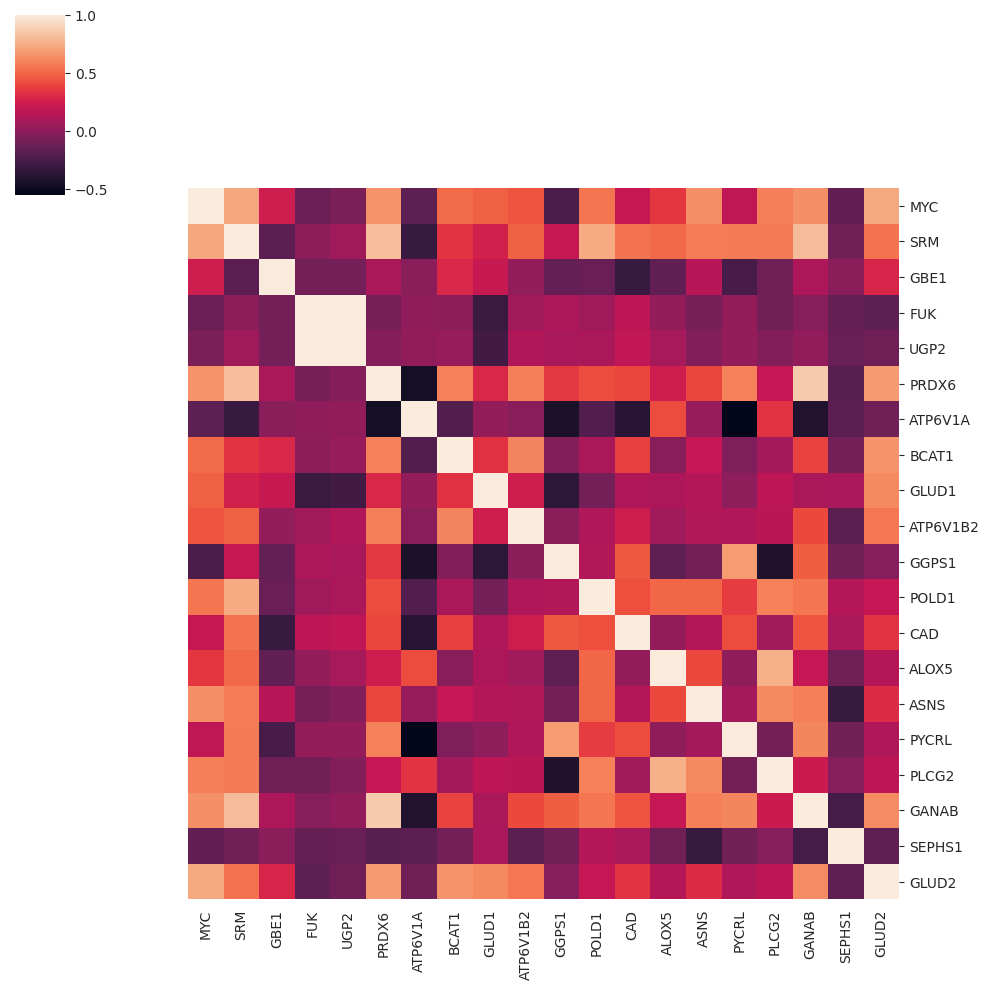

In [3]:
cancer_data = pd.read_csv("cancer_data.txt", sep="\t", index_col=0)
sns.clustermap(cancer_data.corr(), row_cluster=False, col_cluster=False)
plt.show()


## Section 02 - Heatmaps and Hierarchical Clustering
1. Consider the full iris data set without the Species column for clustering. Create a pretty heatmap
with the library sns.clustermap of the data without clustering.
2. Now, create a pretty heatmap using complete linkage clustering of the rows of the data set. Hint:
You can specify a clustering method with the method argument in sns.clustermap
3. Compute the row clustering using complete linkage clustering and partition the data into 3 clusters.
Hint: You can use sklearn.cluster.AgglomerativeClustering().
4. Annotate the rows of the heatmap with the Species column of the iris dataset and the three clusters
from complete linkage clustering. What do you observe when you compare the clustering and the species
labels?

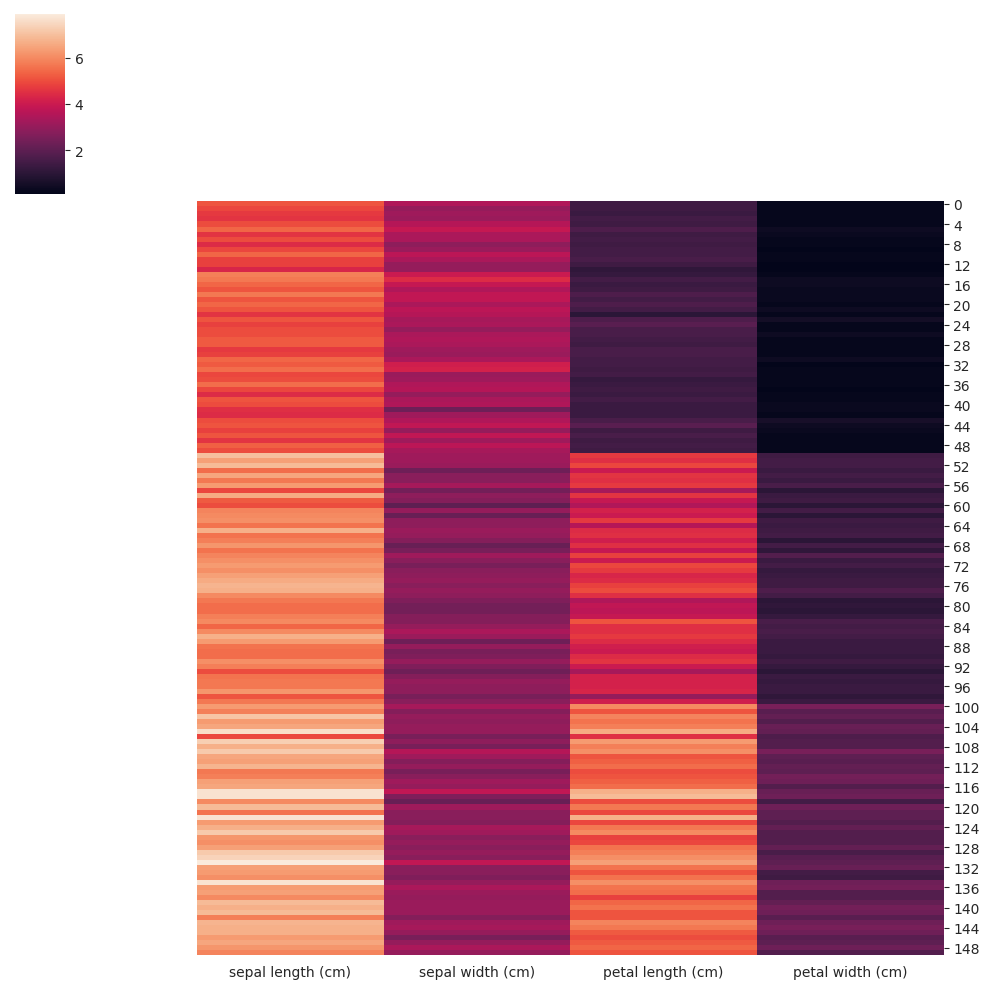

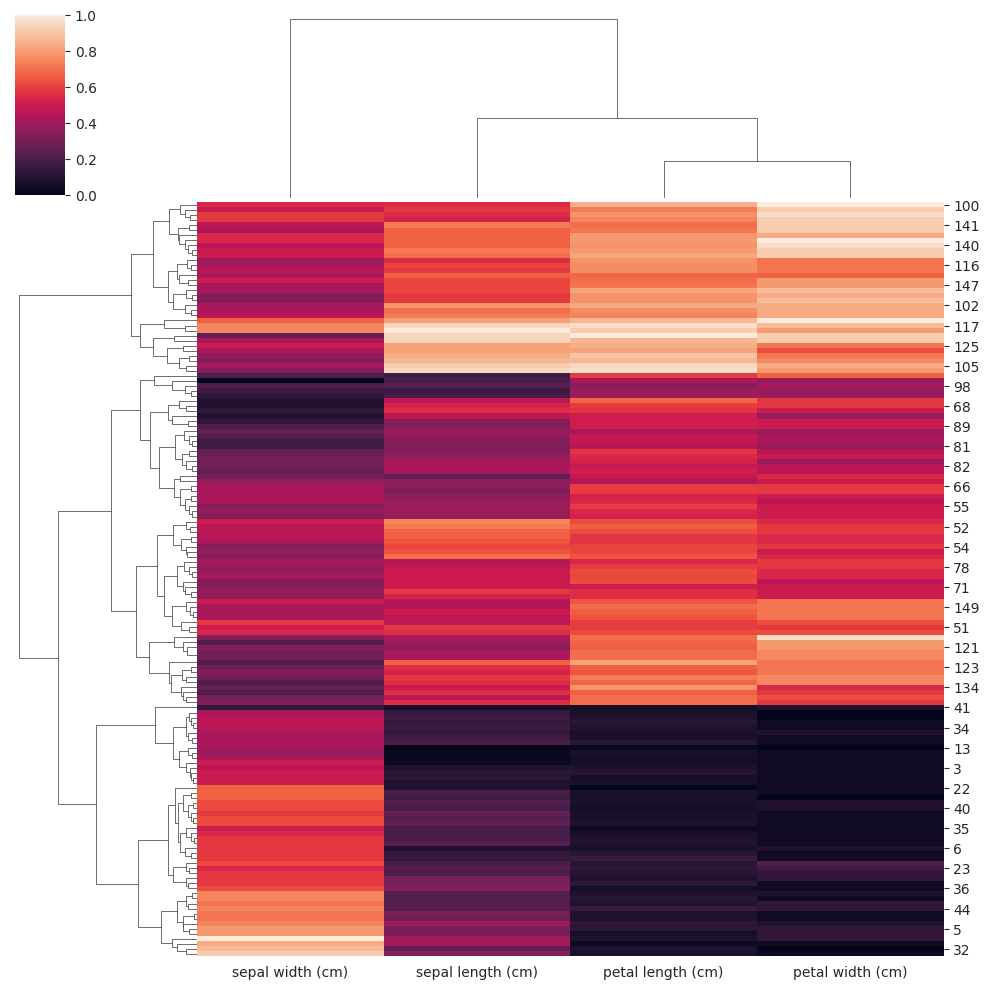

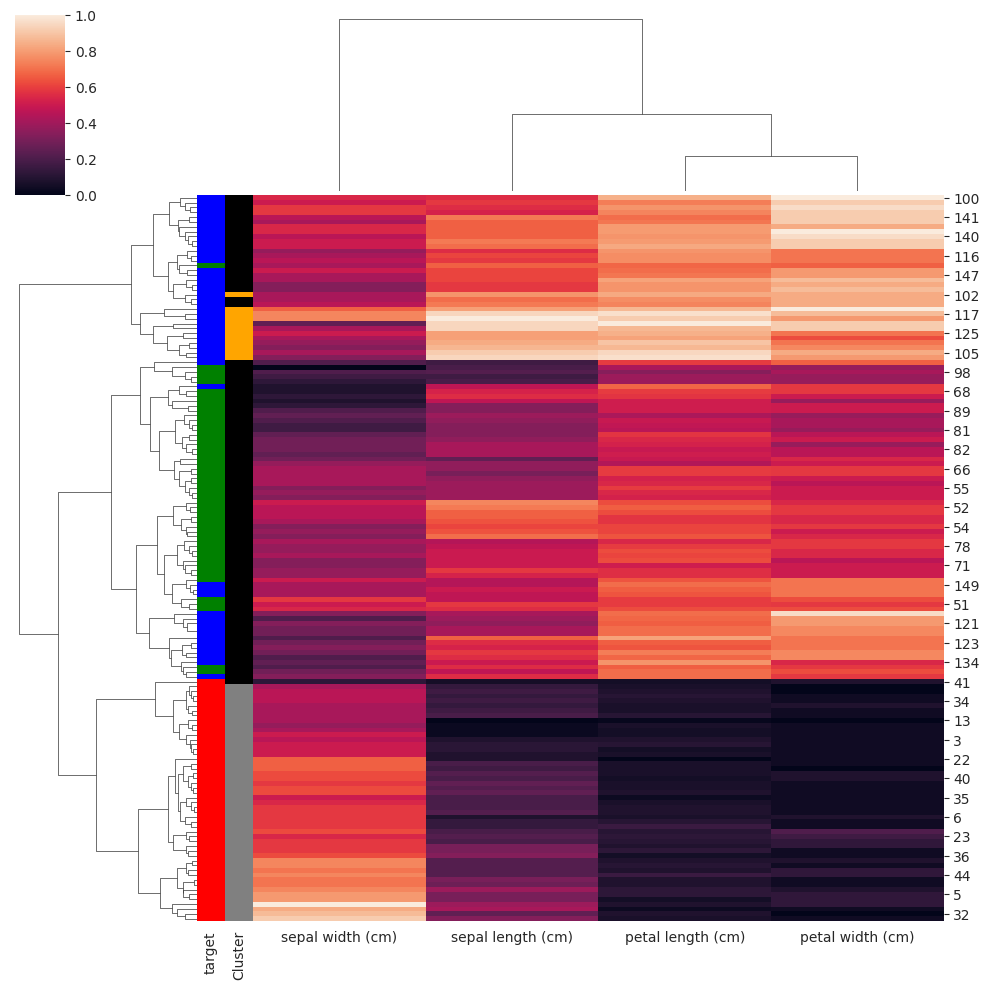

In [22]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
                  for s in iris['target']]
numeric_df = iris_df.drop(columns=['target'])   # drop target for heatmap

iris_df.head()

sns.clustermap(numeric_df, row_cluster=False, col_cluster=False) # 1.

sns.clustermap(
    numeric_df,
    standard_scale=1,
    row_cluster=True,
    col_cluster=True,
    method='complete' # complete linkage
) # 2.
plt.show()

x_iris = sklearn.preprocessing.StandardScaler().fit_transform(numeric_df. iloc[:,:-1])
hc = sklearn.cluster.AgglomerativeClustering(n_clusters=3, linkage='complete').fit(x_iris) # 3.

clusters = hc.labels_
clusters[:10]

iris_df["Cluster"] = clusters
species_palette = {"setosa": "red", "versicolor": "green", "virginica": "blue"}
cluster_palette = {0: "black", 1: "gray", 2: "orange"}
row_colors = pd.DataFrame({
    "target": iris_df["target"].map(species_palette),
    "Cluster": iris_df["Cluster"].map(cluster_palette)
})
sns.clustermap(
    numeric_df,
    standard_scale=1,
    method='complete',
    row_colors=row_colors,
)
plt.show()

# Section 04 - Clustering and Heatmaps
In this section, we aim to compare two different clustering algorithms - hierarchical clustering and k-means
clustering.
1. This plot represents a random initialization of a k-means algorithm with k=2. X1, X2 are the randomly
positioned centroids and A to E are the points of the 2-dimensional dataset. Calculate the new positions
of the centroids after the first iteration using the Euclidean distance. Hint: You can solve this exercise
either with pen and paper or using Python.

In [23]:
centroid1 = np.array([6, 9])
centroid2 = np.array([3, 3])

points = np.array([[4, 6], [5, 8], [6, 4], [8, 5], [10, 7]])

def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def assign_clusters(points, c1, c2):
    clusters = []
    for p in points:
        d1 = euclidean_distance(p, c1)
        d2 = euclidean_distance(p, c2)
        clusters.append(1 if d1 < d2 else 2)
    return np.array(clusters)

def update_centroid(points, cluster_labels, cluster_id):
    cluster_points = points[cluster_labels == cluster_id]
    if len(cluster_points) > 0:
        return cluster_points.mean(axis=0)
    return None

cluster_labels = assign_clusters(points, centroid1, centroid2)

new_centroid1 = update_centroid(points, cluster_labels, 1)
new_centroid2 = update_centroid(points, cluster_labels, 2)

cluster_labels, new_centroid1, new_centroid2


(array([2, 1, 2, 1, 1]), array([7.66666667, 6.66666667]), array([5., 5.]))

2. Perform k-means clustering on the iris data set with 𝑘 = 3

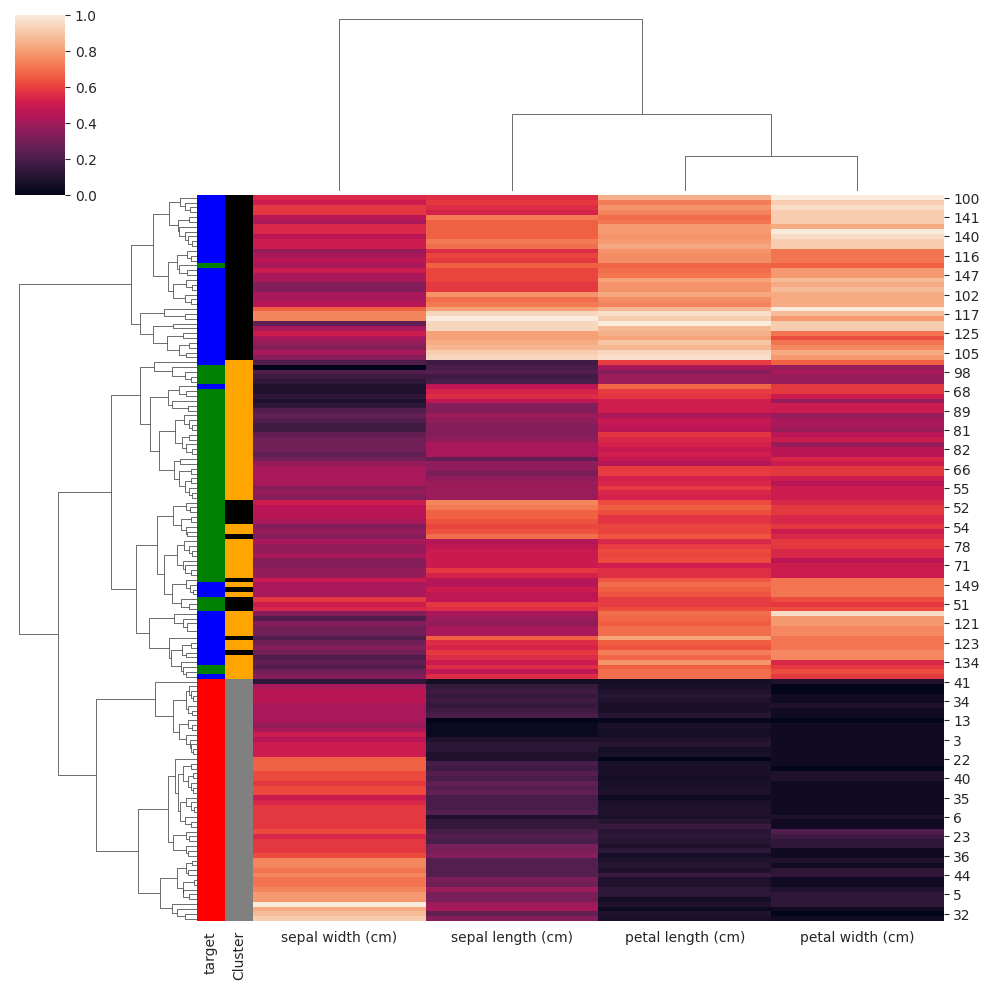

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_scaled)

iris_df["Cluster"] = clusters
species_palette = {"setosa": "red", "versicolor": "green", "virginica": "blue"}
cluster_palette = {0: "black", 1: "gray", 2: "orange"}

row_colors = pd.DataFrame({
    "target": iris_df["target"].map(species_palette),
    "Cluster": iris_df["Cluster"].map(cluster_palette)
})

# --- 5. Clustermap on numeric_df ---
sns.clustermap(
    numeric_df,          # <- your request: use numeric_df
    standard_scale=1,
    method='complete',
    row_colors=row_colors
)

plt.show()

3. Reproduce section 2 from the tutorial. Use the pd.DataFrame.value_counts() method to compare the partitions from the complete linkage and k-means clustering.

In [49]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage="complete")
hc_labels = hc.fit_predict(X_scaled)
iris_df["HC_Complete"] = hc_labels

kmeans = KMeans(n_clusters=3, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)
iris_df["KM_Clusters"] = km_labels

comparison = iris_df[["HC_Complete", "KM_Clusters"]].value_counts()
print("Comparison of partitions:\n")
print(comparison)

Comparison of partitions:

HC_Complete  KM_Clusters
0            0              77
1            1              33
2            0              19
1            2              16
2            2               5
Name: count, dtype: int64


4. Create a heatmap using complete clustering of the rows annotated with the species and both clustering
results - complete linkage clustering and the k-means clustering. What do you observe when you compare
the two different clustering algorithms and the species labels?

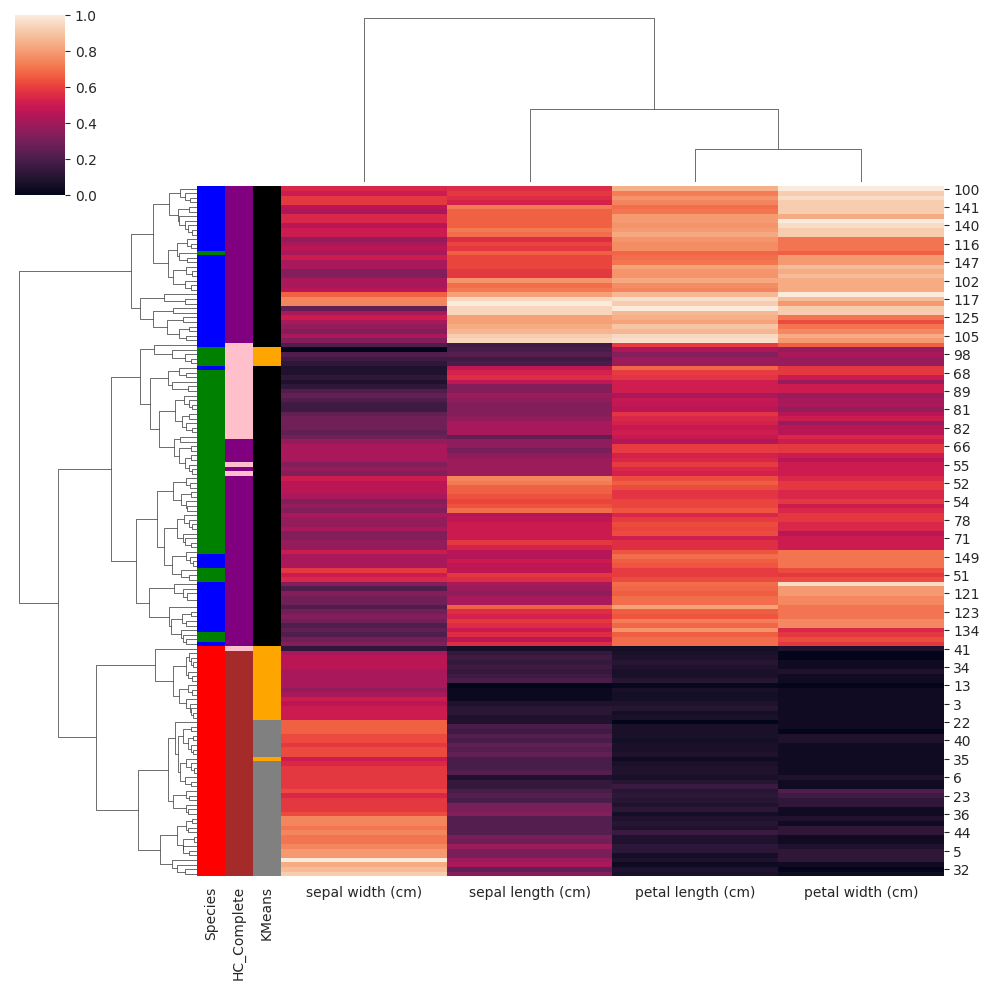

In [50]:
import seaborn as sns

species_palette = {"setosa": "red", "versicolor": "green", "virginica": "blue"}
hc_palette = {0:"purple", 1:"brown", 2:"pink"}
km_palette = {0:"black", 1:"gray", 2:"orange"}

row_colors = pd.DataFrame({
    "Species": iris_df["target"].map(species_palette),
    "HC_Complete": iris_df["HC_Complete"].map(hc_palette),
    "KMeans": iris_df["KM_Clusters"].map(km_palette)
})

sns.clustermap(
    numeric_df,
    standard_scale=1,
    row_cluster=True,
    col_cluster=True,
    method='complete',
    row_colors=row_colors
)
plt.show()

Section 05 - Cluster Comparison
1. Compute the pairwise Rand indices between the clustering results from the previous sections (complete,
average and k-means) and species label. Hint: sklearn.metrics.rand_score().
2. Visualize the pair wise Rand indices with a pretty heatmap. What is the best clustering in this scenario
according to the computed Rand indices? - SEEMS TO BE hc

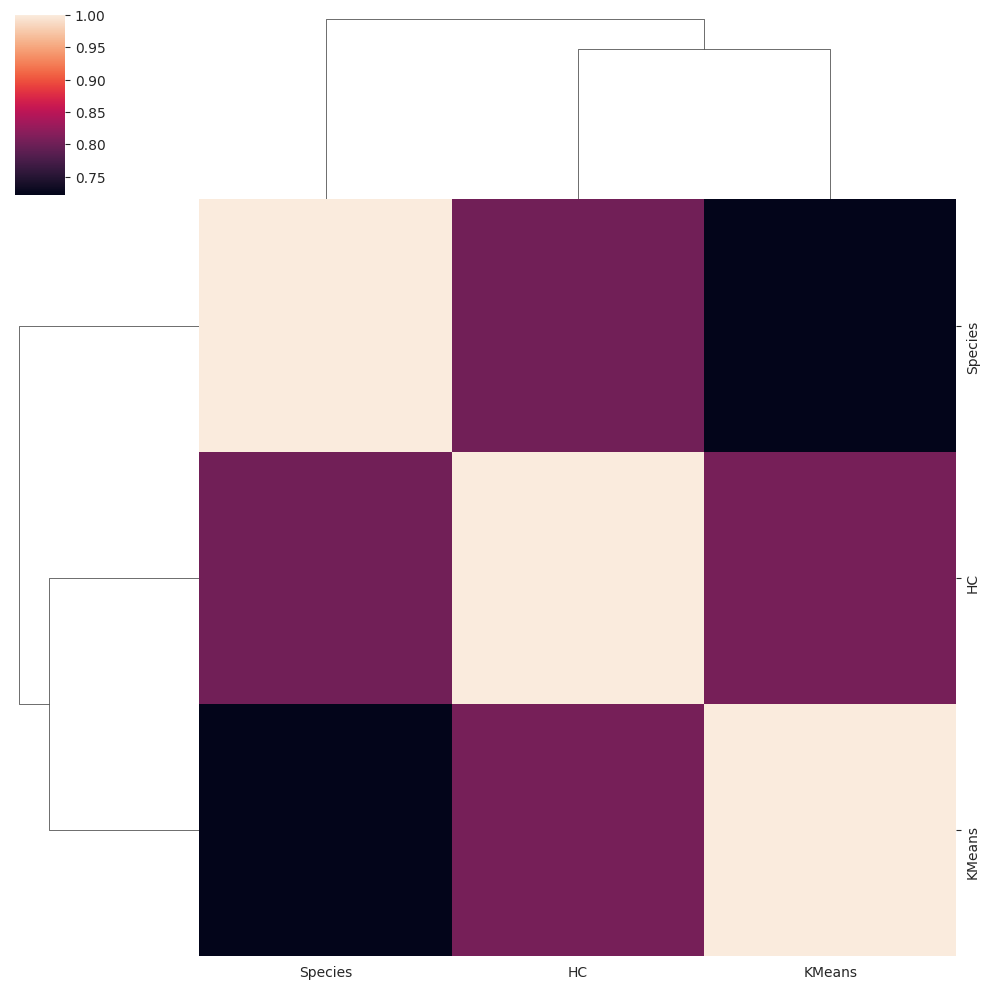

In [56]:
from sklearn.metrics import rand_score

results = [iris_df["HC_Complete"], iris_df["KM_Clusters"], iris_df["target"]]
labels = ["HC", "KMeans", "Species"]
df = pd.DataFrame(
    [[rand_score(a, b) for b in results] for a in results],
    index=labels,
    columns=labels
)

sns.clustermap(
    df
) #

# Section 07 - Dimensionality reduction with PCA
1. Let 𝑋 be the iris data set without the Species column and only for the species setosa. Perform PCA
on 𝑋. Make sure that you scale and center the data before performing PCA.
2. Which proportion of the variance is explained by each principle component?
3. Compute the projection of 𝑋 from the PCA result and plot the projection on the first two principle
components. Hint: PCA.transform(). Additionally, look at the biplot and come up with an interpretation
of the first principal component.
4. Plot the first principal component against the other variables in the dataset and discuss whether this
supports your previously stated interpretation.
5. Repeat the steps 1 - 4 for all species jointly (not only setosa). Discuss whether your original
interpretation of the first principal component changed when performing the PCA for all species jointly.
Use color to differentiate between the species in your plots.

[0.51463505 0.25554456 0.16695506 0.06286532 0.        ]


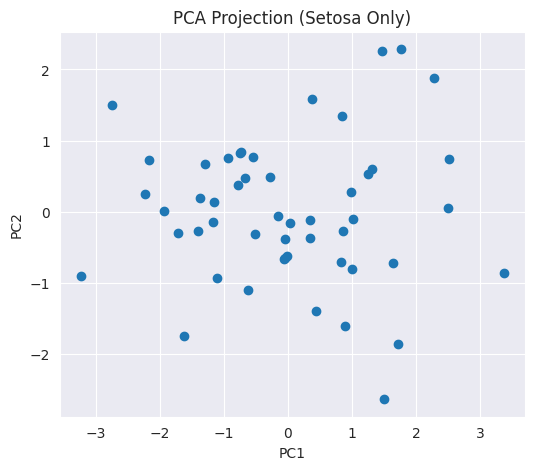

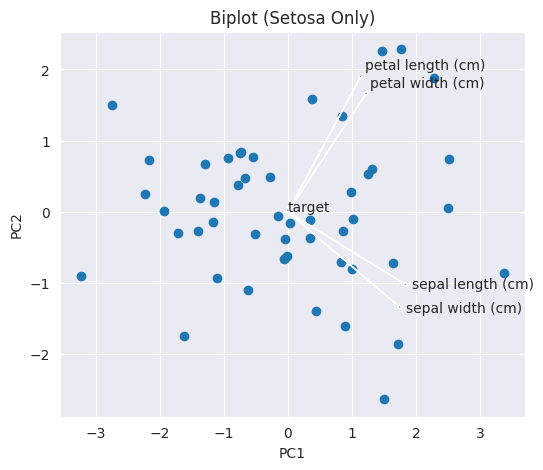

In [102]:
from sklearn.decomposition import PCA

iris = load_iris(as_frame=True)
iris_df = iris['frame']

setosa_iris_df = iris_df[iris_df.target == 0]

scaler = StandardScaler()
X_setosa_scaled = scaler.fit_transform(setosa_iris_df)
pca_setosa = PCA()
pca_setosa.fit(X_setosa_scaled)

explained_setosa = pca_setosa.explained_variance_ratio_
# Goes from PC1, PC2, PC3, PC4
print(explained_setosa)
proj_setosa = pca_setosa.transform(X_setosa_scaled)
plt.figure(figsize=(6,5))
plt.scatter(proj_setosa[:,0], proj_setosa[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Setosa Only)")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(proj_setosa[:,0], proj_setosa[:,1])

for i, feature in enumerate(setosa_iris_df.columns):
    plt.arrow(0,0, pca_setosa.components_[0,i]*3, pca_setosa.components_[1,i]*3, head_width=0.05)
    plt.text(pca_setosa.components_[0,i]*3.2, pca_setosa.components_[1,i]*3.2, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot (Setosa Only)")
plt.show()

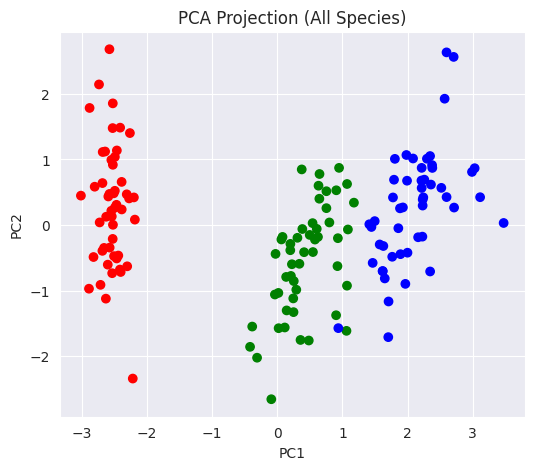

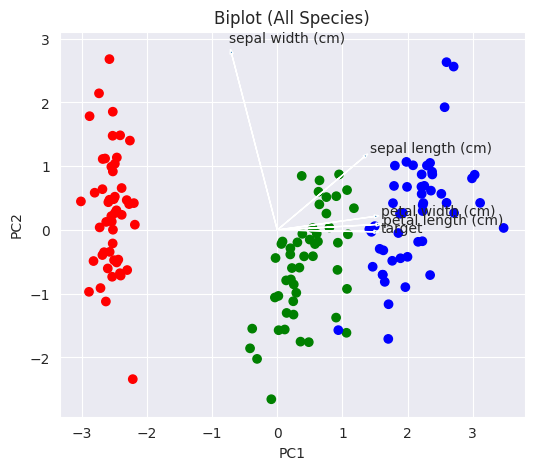

(array([0.51463505, 0.25554456, 0.16695506, 0.06286532, 0.        ]),
 array([0.76740358, 0.18282727, 0.03724523, 0.00841722, 0.0041067 ]))

In [104]:
X_all_scaled = scaler.fit_transform(iris_df)

pca_all = PCA()
pca_all.fit(X_all_scaled)

explained_all = pca_all.explained_variance_ratio_
proj_all = pca_all.transform(X_all_scaled)

colors = ['red' if s==0 else 'green' if s==1 else 'blue' for s in iris_df['target']]

plt.figure(figsize=(6,5))
plt.scatter(proj_all[:,0], proj_all[:,1], c=colors)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (All Species)")
plt.show()

# Biplot (All Species)
plt.figure(figsize=(6,5))
plt.scatter(proj_all[:,0], proj_all[:,1], c=colors)

for i, feature in enumerate(iris_df.columns):
    plt.arrow(0,0, pca_all.components_[0,i]*3, pca_all.components_[1,i]*3, head_width=0.05)
    plt.text(pca_all.components_[0,i]*3.2, pca_all.components_[1,i]*3.2, feature)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot (All Species)")
plt.show()

explained_setosa, explained_all